# Classifying messages as spam or not spam

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
# It Converts text into a numeric matrix (Bag of words). Each unique word becomes a "feature". Each message is represented as a vector of word counts
from sklearn.feature_extraction.text import CountVectorizer
# This implements multinomial naive bayes classifier. This is ideal for text classification
from sklearn.naive_bayes import MultinomialNB
# This is a class for counting elements (like word frequencies)
from collections import Counter
# ConfusionMatrixDisplay -> visualizes the confusion matrix nicely
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay

In [2]:
# Create some sample data

data = pd.DataFrame({
    "label": [
        "ham", "ham", "spam", "ham", "spam", "ham", "spam", "spam", "ham", "spam",
        "ham", "spam", "ham", "ham", "spam", "ham", "spam", "ham", "spam", "ham"
    ],
    "message": [
        "Hey, are we still on for dinner tonight?",
        "Can you send me the report by evening?",
        "Congratulations! You’ve won a free vacation to Hawaii!",
        "Let’s meet at the cafe near your office.",
        "You’ve been selected for a $1000 Walmart gift card. Claim now!",
        "Don’t forget about the team meeting tomorrow morning.",
        "Win a brand new iPhone by clicking this link!",
        "URGENT! Your account has been compromised. Verify immediately!",
        "Happy birthday! Hope you have a great day 🎉",
        "You have won lottery cash prize. Send your bank details.",
        "Lunch at 1 pm?",
        "Get cheap loans approved instantly. Apply now!",
        "I’ll call you later when I’m free.",
        "See you tomorrow at the conference.",
        "You are the lucky winner! Call now to claim your prize.",
        "Please review the attached document.",
        "Claim your free Netflix subscription today!",
        "Don’t forget to lock the door.",
        "Limited time offer! Buy 1 get 1 free!",
        "Meeting postponed to 3 PM."
    ]
})
data.head()

,label,message
0,ham,"Hey, are we still on for dinner tonight?"
1,ham,Can you send me the report by evening?
2,spam,Congratulations! You’ve won a free vacation to...
3,ham,Let’s meet at the cafe near your office.
4,spam,You’ve been selected for a $1000 Walmart gift ...


In [3]:
# Encode labels --> Converts categorical labels into numeric form using a dictionary mapping
data["label_num"] = data["label"].map({"ham":0, "spam":1})
data.head()

,label,message,label_num
0,ham,"Hey, are we still on for dinner tonight?",0
1,ham,Can you send me the report by evening?,0
2,spam,Congratulations! You’ve won a free vacation to...,1
3,ham,Let’s meet at the cafe near your office.,0
4,spam,You’ve been selected for a $1000 Walmart gift ...,1


In [4]:
# Train_test_split
X_train, X_test, y_train, y_test = train_test_split(data["message"], data["label_num"], test_size=0.3, random_state=42)

In [5]:
# Convert text to numeric form (Bag of words)

# The problem is that models like Naive Bayes dont understand text, they need numerical input. So we must represent each message as a vector of numbers. This is called text vectorization
vectorizer = CountVectorizer(stop_words="english")
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [6]:
# Train Naive Bayes Model
model = MultinomialNB()
model.fit(X_train_vec, y_train)
y_pred = model.predict(X_test_vec)

In [7]:
# Evaluate model
print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

              precision    recall  f1-score   support

         ham       1.00      0.17      0.29         6
        spam       0.00      0.00      0.00         0

    accuracy                           0.17         6
   macro avg       0.50      0.08      0.14         6
weighted avg       1.00      0.17      0.29         6



D:\Complete DataScience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Complete DataScience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Complete DataScience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


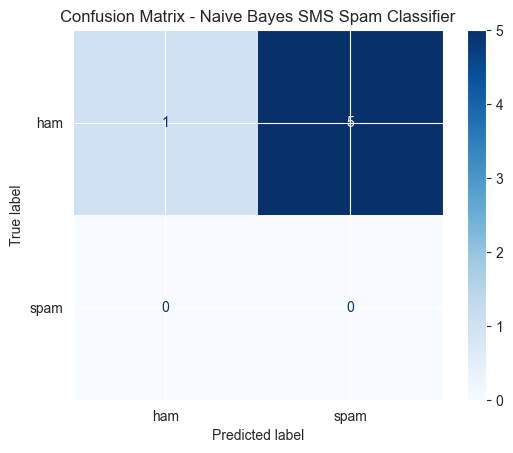

In [8]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham", "spam"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes SMS Spam Classifier")
plt.show()

In [9]:
#Visualize most common words
spam_words = " ".join(data[data["label"] == "spam"]["message"]).lower().split()
ham_words = " ".join(data[data["label"] == "ham"]["message"]).lower().split()

In [10]:
spam_freq = Counter(spam_words)
ham_freq = Counter(ham_words)

In [11]:
top_spam = dict(spam_freq.most_common(10))
top_ham = dict(ham_freq.most_common(10))

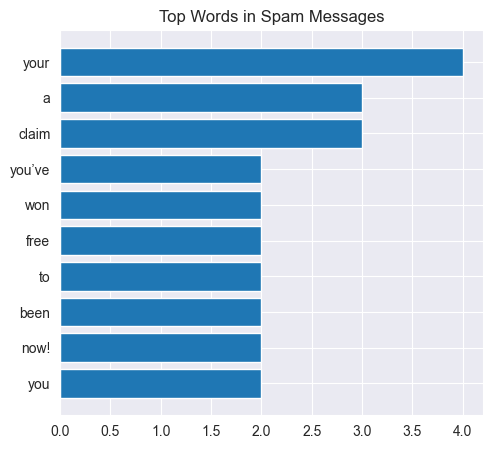

In [12]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.barh(list(top_spam.keys()), list(top_spam.values()))
plt.title("Top Words in Spam Messages")
plt.gca().invert_yaxis()

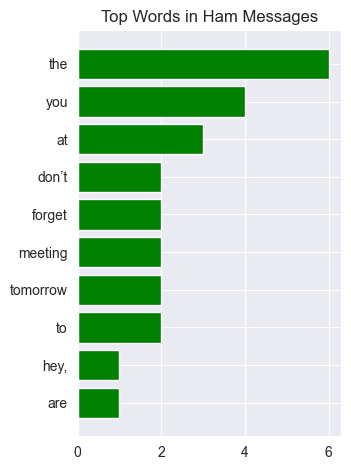

In [13]:
plt.subplot(1,2,2)
plt.barh(list(top_ham.keys()), list(top_ham.values()), color='green')
plt.title("Top Words in Ham Messages")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()